# Imports and functions

In [6]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

def _find_slm_predictive_overlap_npz(results_dir, output_name=None):
    """
    Resolve predictive_overlaps.npz.

    Accepted inputs:
      1. results_dir = direct path to predictive_overlaps.npz
      2. results_dir = folder containing predictive_overlaps.npz
      3. results_dir = parent folder, output_name = subfolder name
    """
    results_dir = Path(results_dir).expanduser()
    fname = "predictive_overlaps.npz"

    if results_dir.is_file():
        if results_dir.name != fname:
            raise FileNotFoundError(f"Expected {fname}, got {results_dir}")
        return results_dir

    candidates = []
    if output_name is not None:
        candidates.append(results_dir / str(output_name) / fname)
    candidates.append(results_dir / fname)

    for path in candidates:
        if path.exists():
            return path

    found = sorted(set(results_dir.glob(f"**/{fname}")))
    if len(found) == 1:
        return found[0]
    if len(found) > 1:
        raise RuntimeError(
            "Found more than one predictive_overlaps.npz file. "
            "Pass output_name or the exact folder.\n"
            + "\n".join(str(p) for p in found[:30])
        )
    raise FileNotFoundError(f"Could not find {fname} under {results_dir}")


def _decode_np_string_array(arr):
    out = []
    for x in np.asarray(arr).tolist():
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return out


def _np_scalar_to_python(x):
    arr = np.asarray(x)
    value = arr.item() if arr.shape == () else arr.tolist()
    if isinstance(value, bytes):
        return value.decode("utf-8")
    return value


def _choose_predictive_time_axis(data, time_key="steps"):
    """Return source checkpoint times and the time-axis label."""
    time_key = str(time_key).lower()
    if time_key in {"steps", "step", "global_updates", "global_update"}:
        if "selected_steps" in data.files:
            return np.asarray(data["selected_steps"], dtype=float), "steps"
    if time_key in {"epochs", "epoch"}:
        if "selected_epochs" in data.files:
            return np.asarray(data["selected_epochs"], dtype=float), "epochs"

    if "selected_steps" in data.files:
        return np.asarray(data["selected_steps"], dtype=float), "steps"
    if "selected_epochs" in data.files:
        return np.asarray(data["selected_epochs"], dtype=float), "epochs"

    raise KeyError("Could not find selected_steps or selected_epochs in predictive_overlaps.npz")


def _target_time_label(data, time_label):
    if time_label == "steps" and "target_step" in data.files:
        return _np_scalar_to_python(np.asarray(data["target_step"]).reshape(-1)[0])
    if time_label == "epochs" and "target_epoch" in data.files:
        return _np_scalar_to_python(np.asarray(data["target_epoch"]).reshape(-1)[0])
    if "target_step" in data.files:
        return _np_scalar_to_python(np.asarray(data["target_step"]).reshape(-1)[0])
    return None


def _resolve_predictive_positions(data, position="mean"):
    """
    Resolve target-token positions in predictive arrays.

    predictive arrays have first axis [num_positions].  If available,
    target_token_positions_1based maps that axis to actual NTP positions i=2,...,d.
    """
    q_key = "predictive_alpha_scores_by_position"
    if q_key in data.files:
        num_pos = np.asarray(data[q_key]).shape[0]
    elif "predictive_q_by_position" in data.files:
        num_pos = np.asarray(data["predictive_q_by_position"]).shape[0]
    else:
        raise KeyError("Could not find predictive_alpha_scores_by_position or predictive_q_by_position")

    if "target_token_positions_1based" in data.files:
        target_positions = np.asarray(data["target_token_positions_1based"], dtype=int).reshape(-1)
    else:
        target_positions = np.arange(2, 2 + num_pos, dtype=int)

    def resolve_one(pos):
        p = int(pos)
        matches = np.where(target_positions == p)[0]
        if len(matches) > 0:
            return int(matches[0])
        if 0 <= p < num_pos:
            return p
        raise ValueError(
            f"Invalid position={p}. Use target positions {target_positions.tolist()} "
            f"or zero-based indices 0..{num_pos - 1}."
        )

    if position is None or str(position).lower() == "mean":
        idx = np.arange(num_pos, dtype=int)
        label = "position average"
    elif isinstance(position, (list, tuple, np.ndarray)):
        idx = np.unique(np.asarray([resolve_one(p) for p in position], dtype=int))
        label = "positions " + ",".join(str(x) for x in target_positions[idx].tolist())
    else:
        idx = np.asarray([resolve_one(position)], dtype=int)
        label = f"target position i={int(target_positions[idx[0]])}"

    return idx, label, target_positions[idx]


def _nanargmax_allow_all_nan(arr, axis=-1):
    """nanargmax, returning -1 where the whole slice is NaN."""
    arr = np.asarray(arr, dtype=float)
    finite = np.isfinite(arr)
    safe = np.where(finite, arr, -np.inf)
    idx = np.argmax(safe, axis=axis)
    any_finite = np.any(finite, axis=axis)
    idx = np.where(any_finite, idx, -1)
    return idx


def _take_best_alpha_scores(scores_by_alpha, alphas, alpha_mode="position_mean"):
    """
    Convert alpha-resolved scores to q[source_layer,target_layer,source_time].

    scores_by_alpha shape: [Ppos, L_source, L_target, K_source_time, A_alpha]
    """
    scores_by_alpha = np.asarray(scores_by_alpha, dtype=float)
    alphas = np.asarray(alphas, dtype=float).reshape(-1)
    alpha_mode = str(alpha_mode).lower()

    if alpha_mode in {"position_mean", "mean_position", "best_position_mean"}:
        # For each source layer, target layer and source time, pick the alpha
        # maximizing the score averaged over the selected positions.
        with np.errstate(invalid="ignore", divide="ignore"):
            score_mean = np.nanmean(scores_by_alpha, axis=0)  # [Ls,Lt,K,A]
        best_idx = _nanargmax_allow_all_nan(score_mean, axis=-1)  # [Ls,Lt,K]
        q = np.full(best_idx.shape, np.nan, dtype=float)
        best_alpha = np.full(best_idx.shape, np.nan, dtype=float)
        valid = best_idx >= 0
        if np.any(valid):
            q[valid] = np.take_along_axis(
                score_mean,
                np.maximum(best_idx, 0)[..., None],
                axis=-1,
            )[..., 0][valid]
            best_alpha[valid] = alphas[best_idx[valid]]
        return q, best_alpha, score_mean, best_idx

    if alpha_mode in {"global", "one_alpha", "single_alpha"}:
        # Pick one alpha for the whole plot family.
        with np.errstate(invalid="ignore", divide="ignore"):
            global_score = np.nanmean(scores_by_alpha, axis=(0, 1, 2, 3))  # [A]
        best_alpha_index = int(_nanargmax_allow_all_nan(global_score, axis=0))
        if best_alpha_index < 0:
            shape = scores_by_alpha.shape[1:4]
            return np.full(shape, np.nan), np.full(shape, np.nan), global_score, best_alpha_index
        with np.errstate(invalid="ignore", divide="ignore"):
            q = np.nanmean(scores_by_alpha[..., best_alpha_index], axis=0)  # [Ls,Lt,K]
        best_alpha = np.full(q.shape, alphas[best_alpha_index], dtype=float)
        return q, best_alpha, global_score, best_alpha_index

    raise ValueError(
        "alpha_mode must be 'position_mean' or 'global'. "
        "Use use_saved_best=True if you want the already saved per-position best scores."
    )


def get_predictive_all_layers_q(
    results_dir,
    output_name=None,
    *,
    position="mean",
    alpha_mode="position_mean",
    use_saved_best=False,
):
    """
    Load predictive_overlaps.npz and return q[source_layer,target_layer,source_time].

    By default this recomputes the displayed q from
    predictive_alpha_scores_by_position by choosing the ridge alpha that gives
    the best selected-position average score for each (source layer, target
    layer, source time). This is usually the cleanest plotting convention.

    If use_saved_best=True, it uses predictive_q_by_position, i.e. the score
    already selected by the overlap script. That can choose different alphas for
    different positions.
    """
    npz_path = _find_slm_predictive_overlap_npz(results_dir, output_name=output_name)
    data = np.load(npz_path, allow_pickle=True)

    if "overlap_target" in data.files:
        target = str(_np_scalar_to_python(data["overlap_target"])).lower()
        if target != "predictive":
            raise ValueError(f"Expected overlap_target='predictive', got {target!r}")

    pos_idx, position_label, selected_target_positions = _resolve_predictive_positions(data, position=position)

    if use_saved_best:
        if "predictive_q_by_position" not in data.files:
            raise KeyError("predictive_q_by_position not found")
        q_pos = np.asarray(data["predictive_q_by_position"], dtype=float)[pos_idx]
        with np.errstate(invalid="ignore", divide="ignore"):
            q = np.nanmean(q_pos, axis=0)  # [Ls,Lt,K]
        best_alpha = None
        alpha_info = None
    else:
        if "predictive_alpha_scores_by_position" not in data.files:
            raise KeyError("predictive_alpha_scores_by_position not found")
        if "ridge_alphas" not in data.files:
            raise KeyError("ridge_alphas not found")
        scores = np.asarray(data["predictive_alpha_scores_by_position"], dtype=float)[pos_idx]
        alphas = np.asarray(data["ridge_alphas"], dtype=float).reshape(-1)
        q, best_alpha, alpha_scores_used, best_alpha_index = _take_best_alpha_scores(
            scores,
            alphas,
            alpha_mode=alpha_mode,
        )
        alpha_info = {
            "ridge_alphas": alphas,
            "alpha_scores_used": alpha_scores_used,
            "best_alpha_index": best_alpha_index,
        }

    if q.ndim != 3:
        raise ValueError(f"Expected q[source_layer,target_layer,time], got shape {q.shape}")

    if "source_layer_names" in data.files:
        source_layer_names = _decode_np_string_array(data["source_layer_names"])
    else:
        source_layer_names = [f"source_layer_{i}" for i in range(q.shape[0])]

    if "target_layer_names" in data.files:
        target_layer_names = _decode_np_string_array(data["target_layer_names"])
    else:
        target_layer_names = [f"target_layer_{i}" for i in range(q.shape[1])]

    info = {
        "npz_path": str(npz_path),
        "position": position,
        "position_label": position_label,
        "selected_position_indices": pos_idx,
        "selected_target_positions_1based": selected_target_positions,
        "alpha_mode": alpha_mode,
        "use_saved_best": bool(use_saved_best),
        "best_alpha": best_alpha,
        "alpha_info": alpha_info,
        "source_layer_names": source_layer_names,
        "target_layer_names": target_layer_names,
        "q_shape": q.shape,
    }
    return q, source_layer_names, target_layer_names, data, info


def plot_predictive_all_source_layers_to_each_target_layer(
    results_dir,
    output_name=None,
    *,
    position="mean",
    alpha_mode="position_mean",
    use_saved_best=False,
    time_key="steps",
    source_layers=None,
    target_layers=None,
    x_mode="absolute",
    xscale="log",
    yscale="linear",
    ylim=None,
    ncols=3,
    figsize_per_panel=(5.8, 4.0),
    linewidth=2.4,
    alpha=0.95,
    marker=None,
    legend_fontsize=7,
    grid=True,
    add_zero_line=True,
    add_one_line=True,
    title_prefix=None,
    cmap="turbo", 
    cmap_min=0.05, 
    cmap_max=0.85
):
    """
    Plot predictive overlap for all source layers l -> each target layer l'.

    Output:
      one panel for each selected target layer l'.
      inside each panel: one curve for every selected source layer l.

    The plotted quantity is q[l,l',t], where t' is the single target checkpoint
    used when predictive_overlaps.npz was created.
    """
    q, source_names, target_names, data, info = get_predictive_all_layers_q(
        results_dir,
        output_name=output_name,
        position=position,
        alpha_mode=alpha_mode,
        use_saved_best=use_saved_best,
    )

    times, actual_time_key = _choose_predictive_time_axis(data, time_key=time_key)
    if len(times) != q.shape[2]:
        raise ValueError(f"Time axis has length {len(times)} but q has {q.shape[2]} source times")

    target_time = _target_time_label(data, actual_time_key)

    def resolve_layers(selection, names, label):
        if selection is None:
            return np.arange(len(names), dtype=int)
        if isinstance(selection, (str, int, np.integer)):
            selection = [selection]
        out = []
        for item in selection:
            if isinstance(item, str):
                if item not in names:
                    raise ValueError(f"{label} {item!r} not found. Available: {names}")
                out.append(names.index(item))
            else:
                j = int(item)
                if j < 0 or j >= len(names):
                    raise ValueError(f"{label} index {j} outside [0,{len(names)-1}]")
                out.append(j)
        return np.asarray(out, dtype=int)

    src_idx = resolve_layers(source_layers, source_names, "source layer")
    tgt_idx = resolve_layers(target_layers, target_names, "target layer")

    colormap = mpl.colormaps.get_cmap(cmap)
    color_values = np.linspace(float(cmap_min), float(cmap_max), len(src_idx))
    source_colors = {
        int(j_src): colormap(color_values[k])
        for k, j_src in enumerate(src_idx)
    }

    if x_mode == "absolute":
        x = times.copy()
        xlabel = rf"$t$ ({actual_time_key})"
    elif x_mode == "delta_to_target":
        if target_time is None:
            raise ValueError("x_mode='delta_to_target' requires target_step/target_epoch in the npz")
        x = times.astype(float) - float(target_time)
        xlabel = rf"$t-t'$ ({actual_time_key})"
    else:
        raise ValueError("x_mode must be 'absolute' or 'delta_to_target'")

    mask = np.isfinite(x)
    if xscale == "log":
        mask &= x > 0
    x_plot = x[mask]
    time_idx = np.where(mask)[0]

    n_panels = len(tgt_idx)
    ncols_eff = max(1, min(int(ncols), n_panels))
    nrows = int(math.ceil(n_panels / ncols_eff))

    fig, axs = plt.subplots(
        nrows,
        ncols_eff,
        figsize=(figsize_per_panel[0] * ncols_eff, figsize_per_panel[1] * nrows),
        squeeze=False,
    )
    axs_flat = axs.ravel()

    for ax, j_tgt in zip(axs_flat, tgt_idx):
        for j_src in src_idx:
            y = q[j_src, j_tgt, time_idx]
            ax.plot(
                x_plot,
                y,
                marker=marker,
                linewidth=linewidth,
                alpha=alpha,
                color=source_colors[int(j_src)],
                label=source_names[j_src],
            )

        if add_zero_line:
            ax.axhline(0.0, color="black", lw=0.8, alpha=0.35)
        if add_one_line:
            ax.axhline(1.0, color="black", lw=0.8, alpha=0.25, linestyle="--")

        ax.set_xlabel(xlabel)
        ax.set_ylabel(r"predictive overlap $q_{l\to l'}(t,t')$")
        ax.set_xscale(xscale)
        ax.set_yscale(yscale)
        if ylim is not None:
            ax.set_ylim(*ylim)
        if grid:
            ax.grid(True, alpha=0.3)

        title = rf"target layer $l'$: {target_names[j_tgt]}"
        if target_time is not None:
            title += "\n" + rf"fixed $t'={float(target_time):g}$ {actual_time_key}"
        if title_prefix is not None:
            title = f"{title_prefix}\n" + title
        ax.set_title(title)
        ax.legend(fontsize=legend_fontsize, frameon=False)

    for ax in axs_flat[n_panels:]:
        ax.axis("off")

    fig.tight_layout()

    info.update({
        "time_key_used": actual_time_key,
        "source_times": times,
        "source_time_plot_mask": mask,
        "target_time": target_time,
        "source_layer_indices": src_idx,
        "target_layer_indices": tgt_idx,
        "plotted_source_layers": [source_names[i] for i in src_idx],
        "plotted_target_layers": [target_names[i] for i in tgt_idx],
    })

    return fig, axs, info


In [13]:
def plot_predictive_same_layer_overlap_vs_time(
    results_dir,
    output_name=None,
    *,
    position="mean",
    alpha_mode="position_mean",
    use_saved_best=False,
    time_key="steps",
    layers=None,
    x_mode="absolute",
    xscale="log",
    yscale="linear",
    ylim=None,
    figsize=(7.2, 5.0),
    linewidth=2.6,
    alpha=0.95,
    marker=None,
    cmap="turbo", 
    cmap_min=0.05, 
    cmap_max=0.85,
    legend_fontsize=8,
    grid=True,
    add_zero_line=True,
    add_one_line=True,
    title=None,
):
    """
    Plot only the same-layer predictive overlap q_{l -> l}(t,t').

    One single axis is created.
    Each curve is one layer l, with target layer l'=l fixed at the single
    target checkpoint t' used when predictive_overlaps.npz was created.

    The plotted quantity is:

        q[l, l, t]

    where q is the normalized explained variance of the learned ridge map
    from H_{t,l} to H_{t',l}.
    """
    import matplotlib as mpl

    q, source_names, target_names, data, info = get_predictive_all_layers_q(
        results_dir,
        output_name=output_name,
        position=position,
        alpha_mode=alpha_mode,
        use_saved_best=use_saved_best,
    )

    if q.ndim != 3:
        raise ValueError(f"Expected q[source_layer,target_layer,time], got shape {q.shape}")

    if q.shape[0] != q.shape[1]:
        raise ValueError(
            "Same-layer plotting requires the same number of source and target layers. "
            f"Got source={q.shape[0]}, target={q.shape[1]}."
        )

    times, actual_time_key = _choose_predictive_time_axis(data, time_key=time_key)
    if len(times) != q.shape[2]:
        raise ValueError(f"Time axis has length {len(times)} but q has {q.shape[2]} source times")

    target_time = _target_time_label(data, actual_time_key)

    def resolve_layers(selection, names):
        if selection is None:
            return np.arange(len(names), dtype=int)

        if isinstance(selection, (str, int, np.integer)):
            selection = [selection]

        out = []
        for item in selection:
            if isinstance(item, str):
                if item not in names:
                    raise ValueError(f"Layer {item!r} not found. Available: {names}")
                out.append(names.index(item))
            else:
                j = int(item)
                if j < 0 or j >= len(names):
                    raise ValueError(f"Layer index {j} outside [0,{len(names)-1}]")
                out.append(j)

        return np.asarray(out, dtype=int)

    layer_idx = resolve_layers(layers, source_names)

    if np.any(layer_idx >= q.shape[1]):
        raise ValueError(
            "Some selected source-layer indices do not exist on the target-layer axis."
        )

    if x_mode == "absolute":
        x = times.copy()
        xlabel = rf"$t$ ({actual_time_key})"
    elif x_mode == "delta_to_target":
        if target_time is None:
            raise ValueError("x_mode='delta_to_target' requires target_step/target_epoch in the npz")
        x = times.astype(float) - float(target_time)
        xlabel = rf"$t-t'$ ({actual_time_key})"
    else:
        raise ValueError("x_mode must be 'absolute' or 'delta_to_target'")

    mask = np.isfinite(x)
    if xscale == "log":
        mask &= x > 0

    x_plot = x[mask]
    time_idx = np.where(mask)[0]

    colormap = mpl.colormaps.get_cmap(cmap)
    color_values = np.linspace(float(cmap_min), float(cmap_max), len(layer_idx))
    layer_colors = {
        int(j): colormap(color_values[k])
        for k, j in enumerate(layer_idx)
    }

    fig, ax = plt.subplots(figsize=figsize)

    for j in layer_idx:
        y = q[j, j, time_idx]

        ax.plot(
            x_plot,
            y,
            marker=marker,
            linewidth=linewidth,
            alpha=alpha,
            color=layer_colors[int(j)],
            label=source_names[j],
        )

    if add_zero_line:
        ax.axhline(0.0, color="black", lw=0.8, alpha=0.35)

    if add_one_line:
        ax.axhline(1.0, color="black", lw=0.8, alpha=0.25, linestyle="--")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"same-layer predictive overlap $q_{l\to l}(t,t')$")
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)

    if ylim is not None:
        ax.set_ylim(*ylim)

    if grid:
        ax.grid(True, alpha=0.3)

    if title is None:
        title_eff = r"Same-layer predictive representation overlap"
        if target_time is not None:
            title_eff += "\n" + rf"fixed $t'={float(target_time):g}$ {actual_time_key}"
    else:
        title_eff = title

    ax.set_title(title_eff)
    ax.legend(fontsize=legend_fontsize, frameon=False)

    fig.tight_layout()

    info.update({
        "time_key_used": actual_time_key,
        "source_times": times,
        "source_time_plot_mask": mask,
        "target_time": target_time,
        "layer_indices": layer_idx,
        "plotted_layers": [source_names[i] for i in layer_idx],
        "same_layer_only": True,
        "cmap": cmap,
        "cmap_min": cmap_min,
        "cmap_max": cmap_max,
    })

    return fig, ax, info

# Runs

## L=3

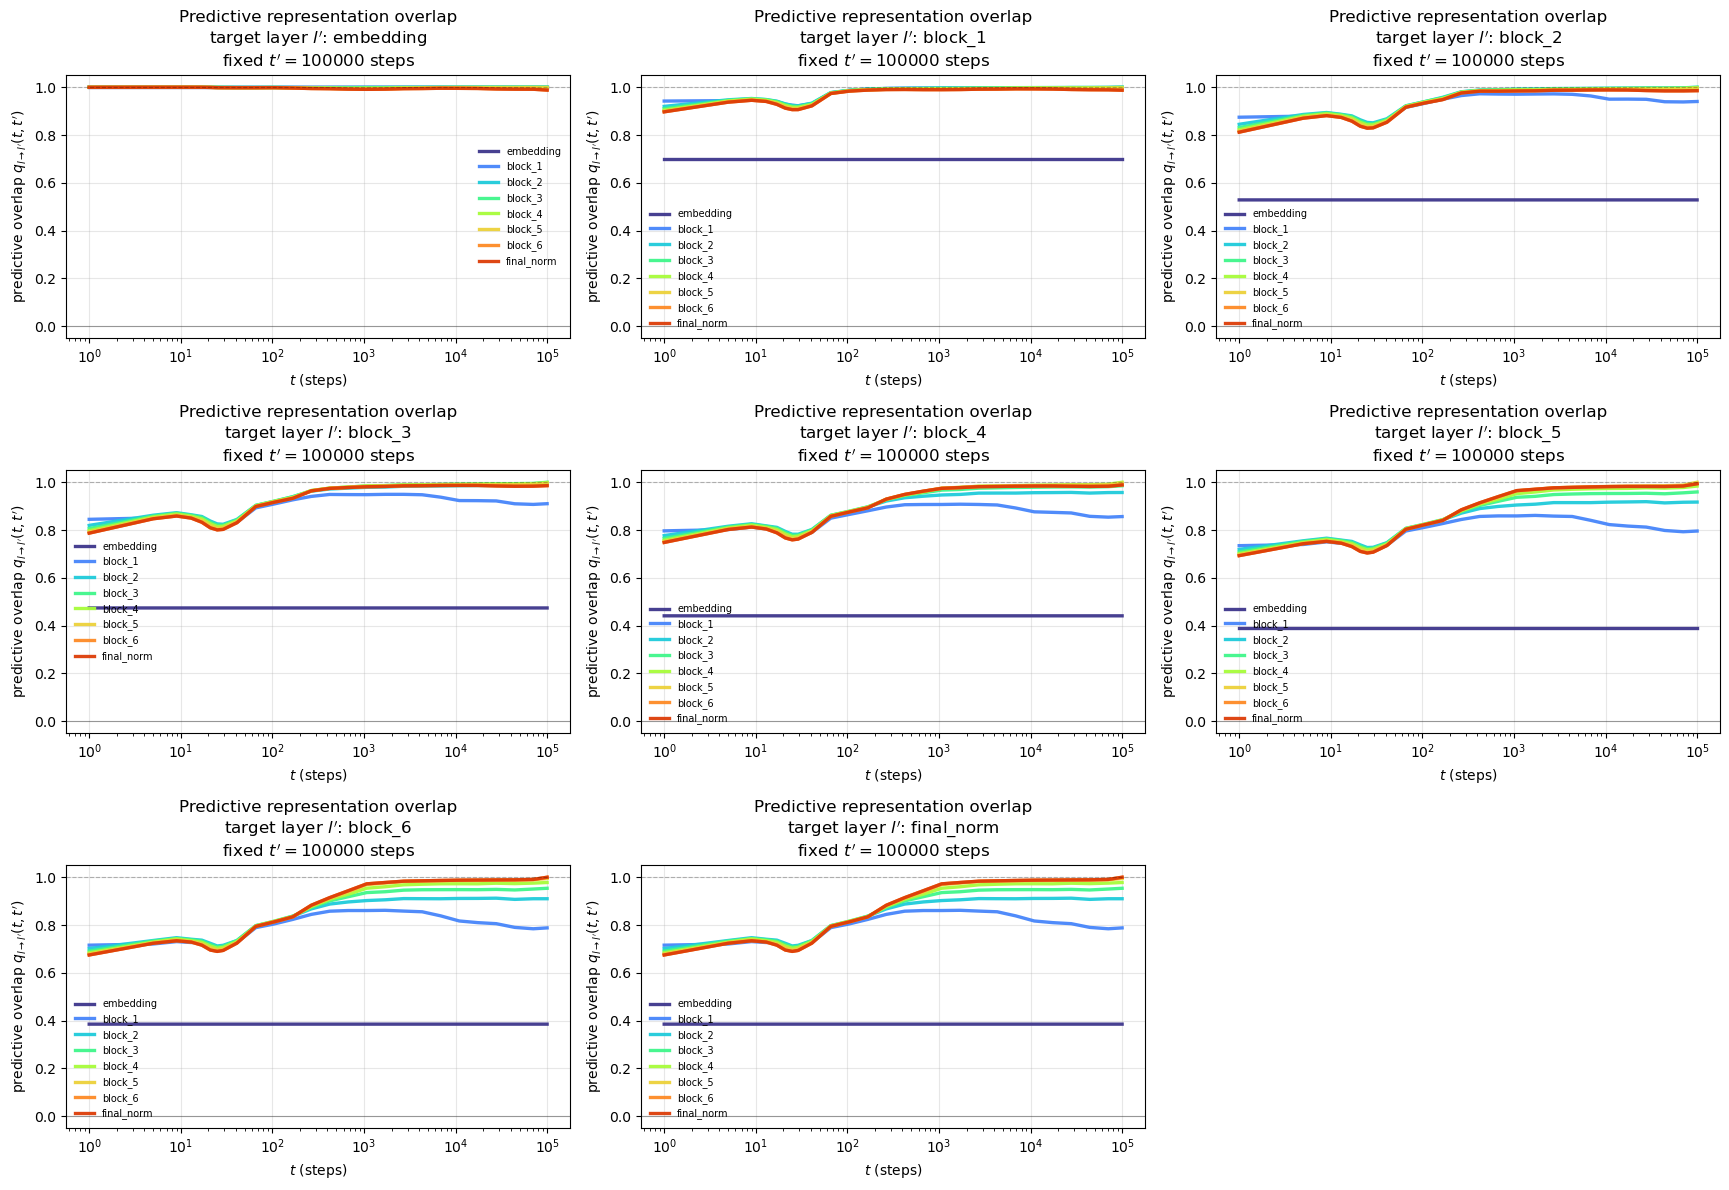

In [7]:

fig, axs, info = plot_predictive_all_source_layers_to_each_target_layer(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_predictive_TR2_ALL_L3_v1/",
    # or:
    # results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/",
    # output_name="YOUR_PREDICTIVE_OUTPUT_NAME",

    position="mean",          # average over token positions
    alpha_mode="position_mean",

    time_key="steps",
    x_mode="absolute",
    xscale="log",
    yscale="linear",

    ylim=None,                # no clipping: negative q values are visible
    ncols=3,
    title_prefix="Predictive representation overlap",
)

/tmp/ipykernel_5873/791204073.py:161: RuntimeWarning: Mean of empty slice
  score_mean = np.nanmean(scores_by_alpha, axis=0)  # [Ls,Lt,K,A]


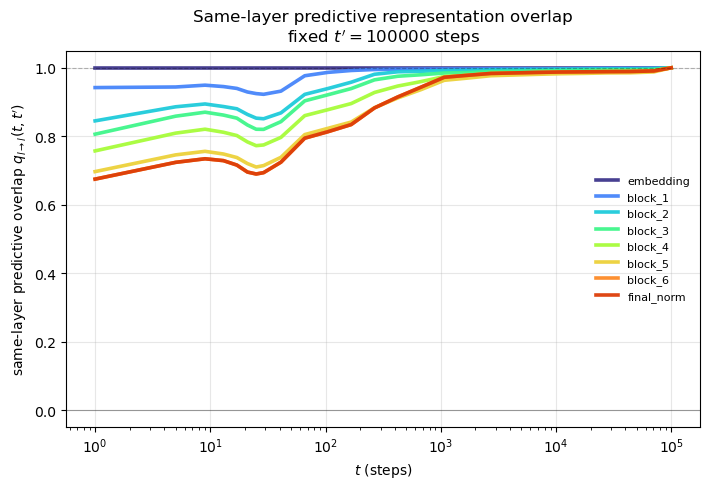

In [21]:
fig, ax, info = plot_predictive_same_layer_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_predictive_TR2_L3_v1/",
    position="mean",
    alpha_mode="position_mean",
    time_key="steps",
    x_mode="absolute",
    xscale="log",
    ylim=None,
)

## L=4

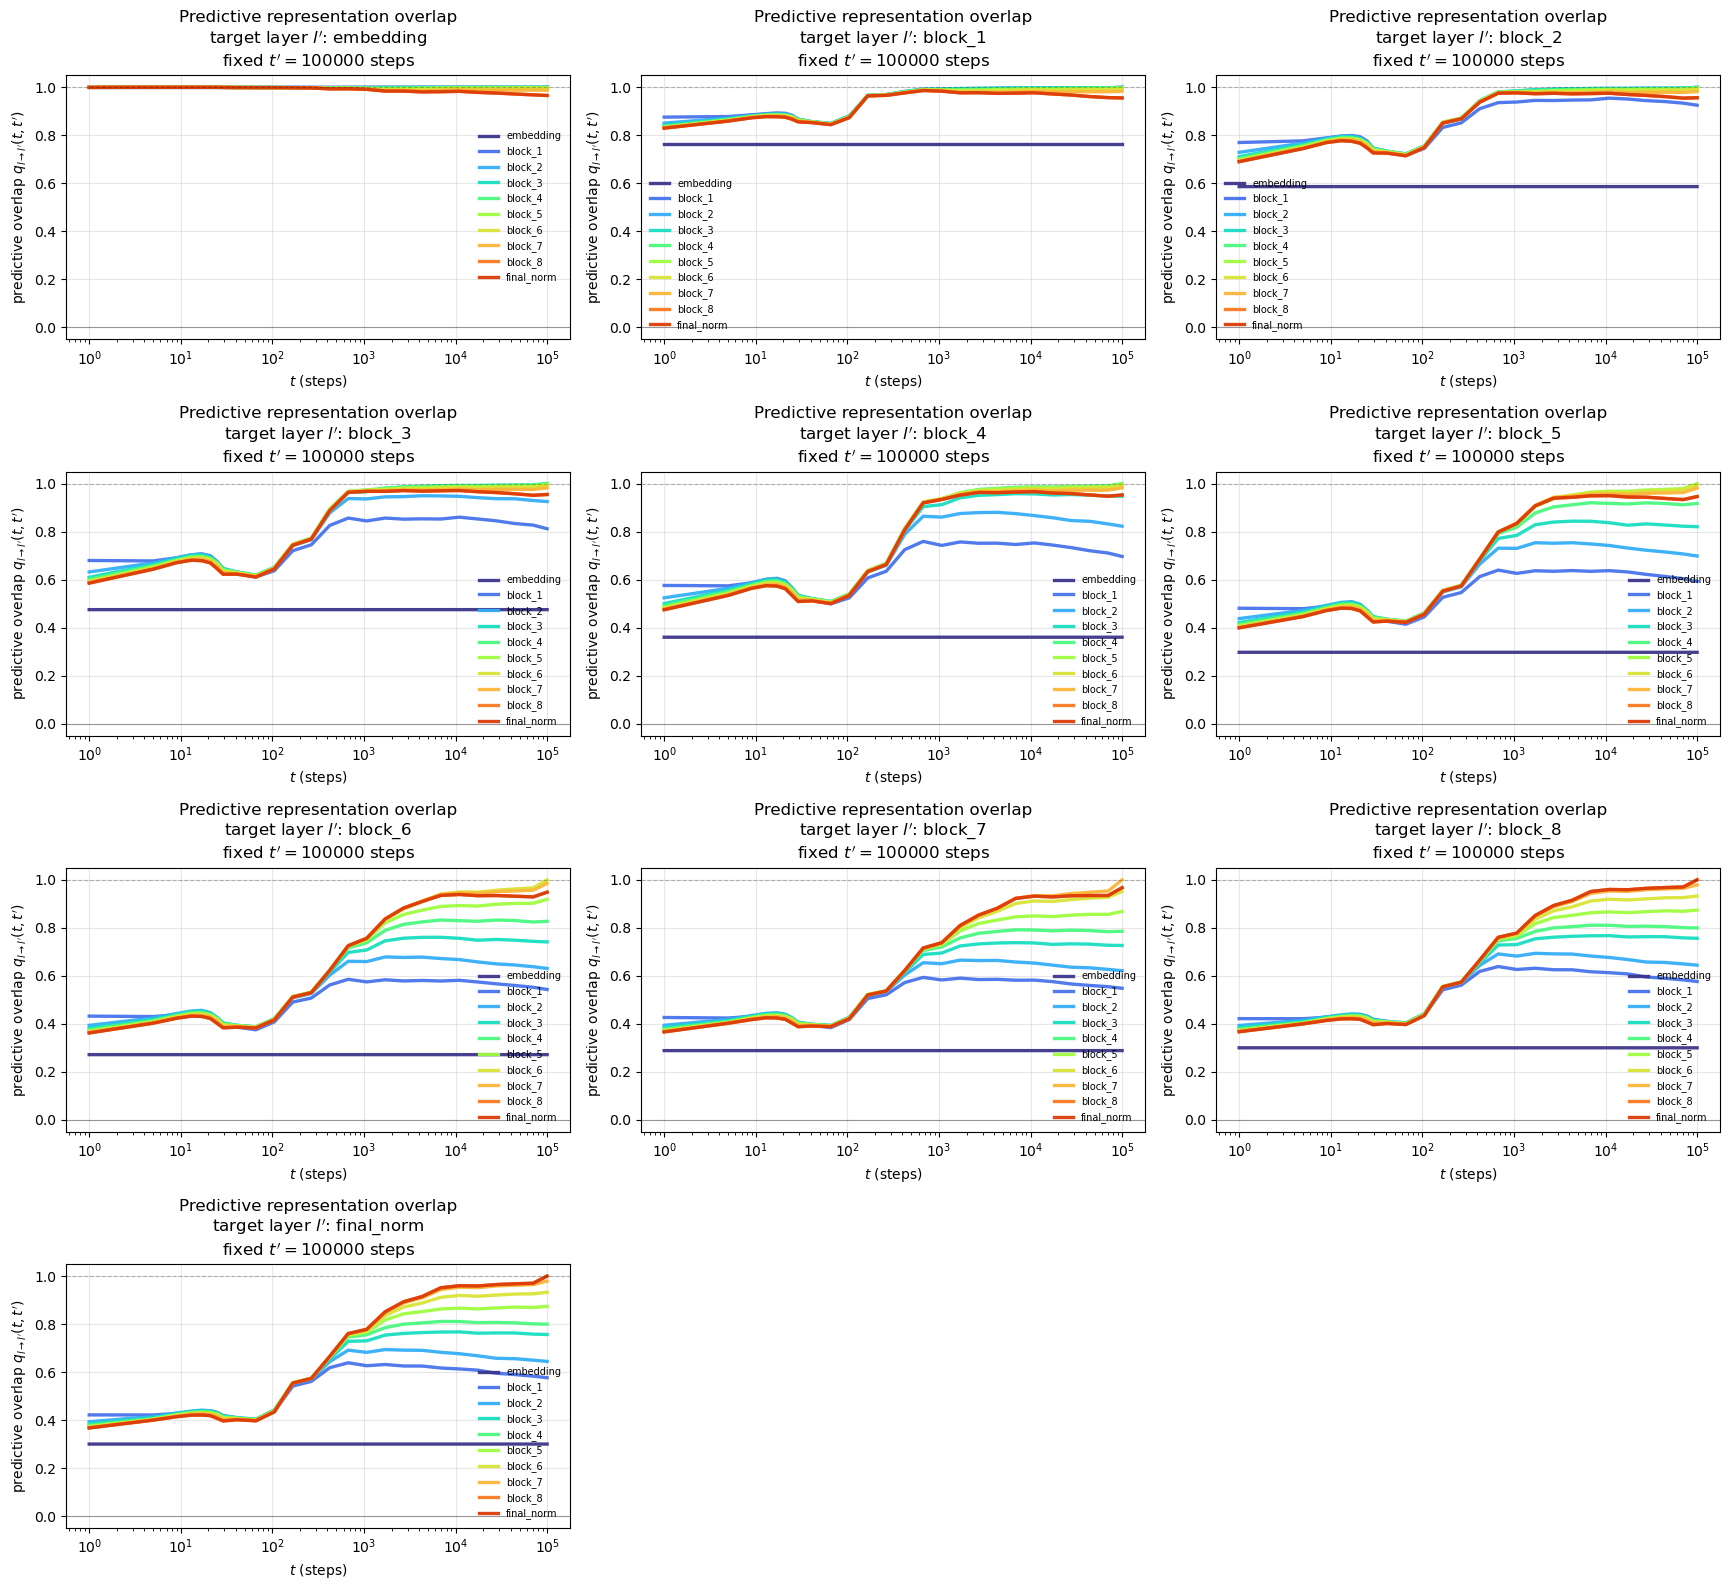

In [8]:

fig, axs, info = plot_predictive_all_source_layers_to_each_target_layer(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_predictive_TR2_ALL_L4_v1/",
    # or:
    # results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/",
    # output_name="YOUR_PREDICTIVE_OUTPUT_NAME",

    position="mean",          # average over token positions
    alpha_mode="position_mean",

    time_key="steps",
    x_mode="absolute",
    xscale="log",
    yscale="linear",

    ylim=None,                # no clipping: negative q values are visible
    ncols=3,
    title_prefix="Predictive representation overlap",
)

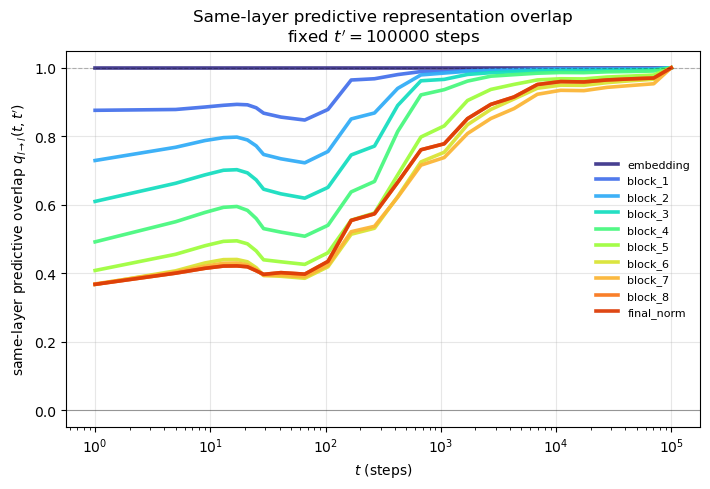

In [17]:
fig, ax, info = plot_predictive_same_layer_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_predictive_TR2_ALL_L4_v1/",
    position="mean",
    alpha_mode="position_mean",
    time_key="steps",
    x_mode="absolute",
    xscale="log",
    ylim=None,
)

## L=5

In [9]:

fig, axs, info = plot_predictive_all_source_layers_to_each_target_layer(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_predictive_TR2_ALL_L5_v1/",
    # or:
    # results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/",
    # output_name="YOUR_PREDICTIVE_OUTPUT_NAME",

    position="mean",          # average over token positions
    alpha_mode="position_mean",

    time_key="steps",
    x_mode="absolute",
    xscale="log",
    yscale="linear",

    ylim=None,                # no clipping: negative q values are visible
    ncols=3,
    title_prefix="Predictive representation overlap",
)

FileNotFoundError: Could not find predictive_overlaps.npz under /mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_predictive_TR2_ALL_L5_v1

## L=6

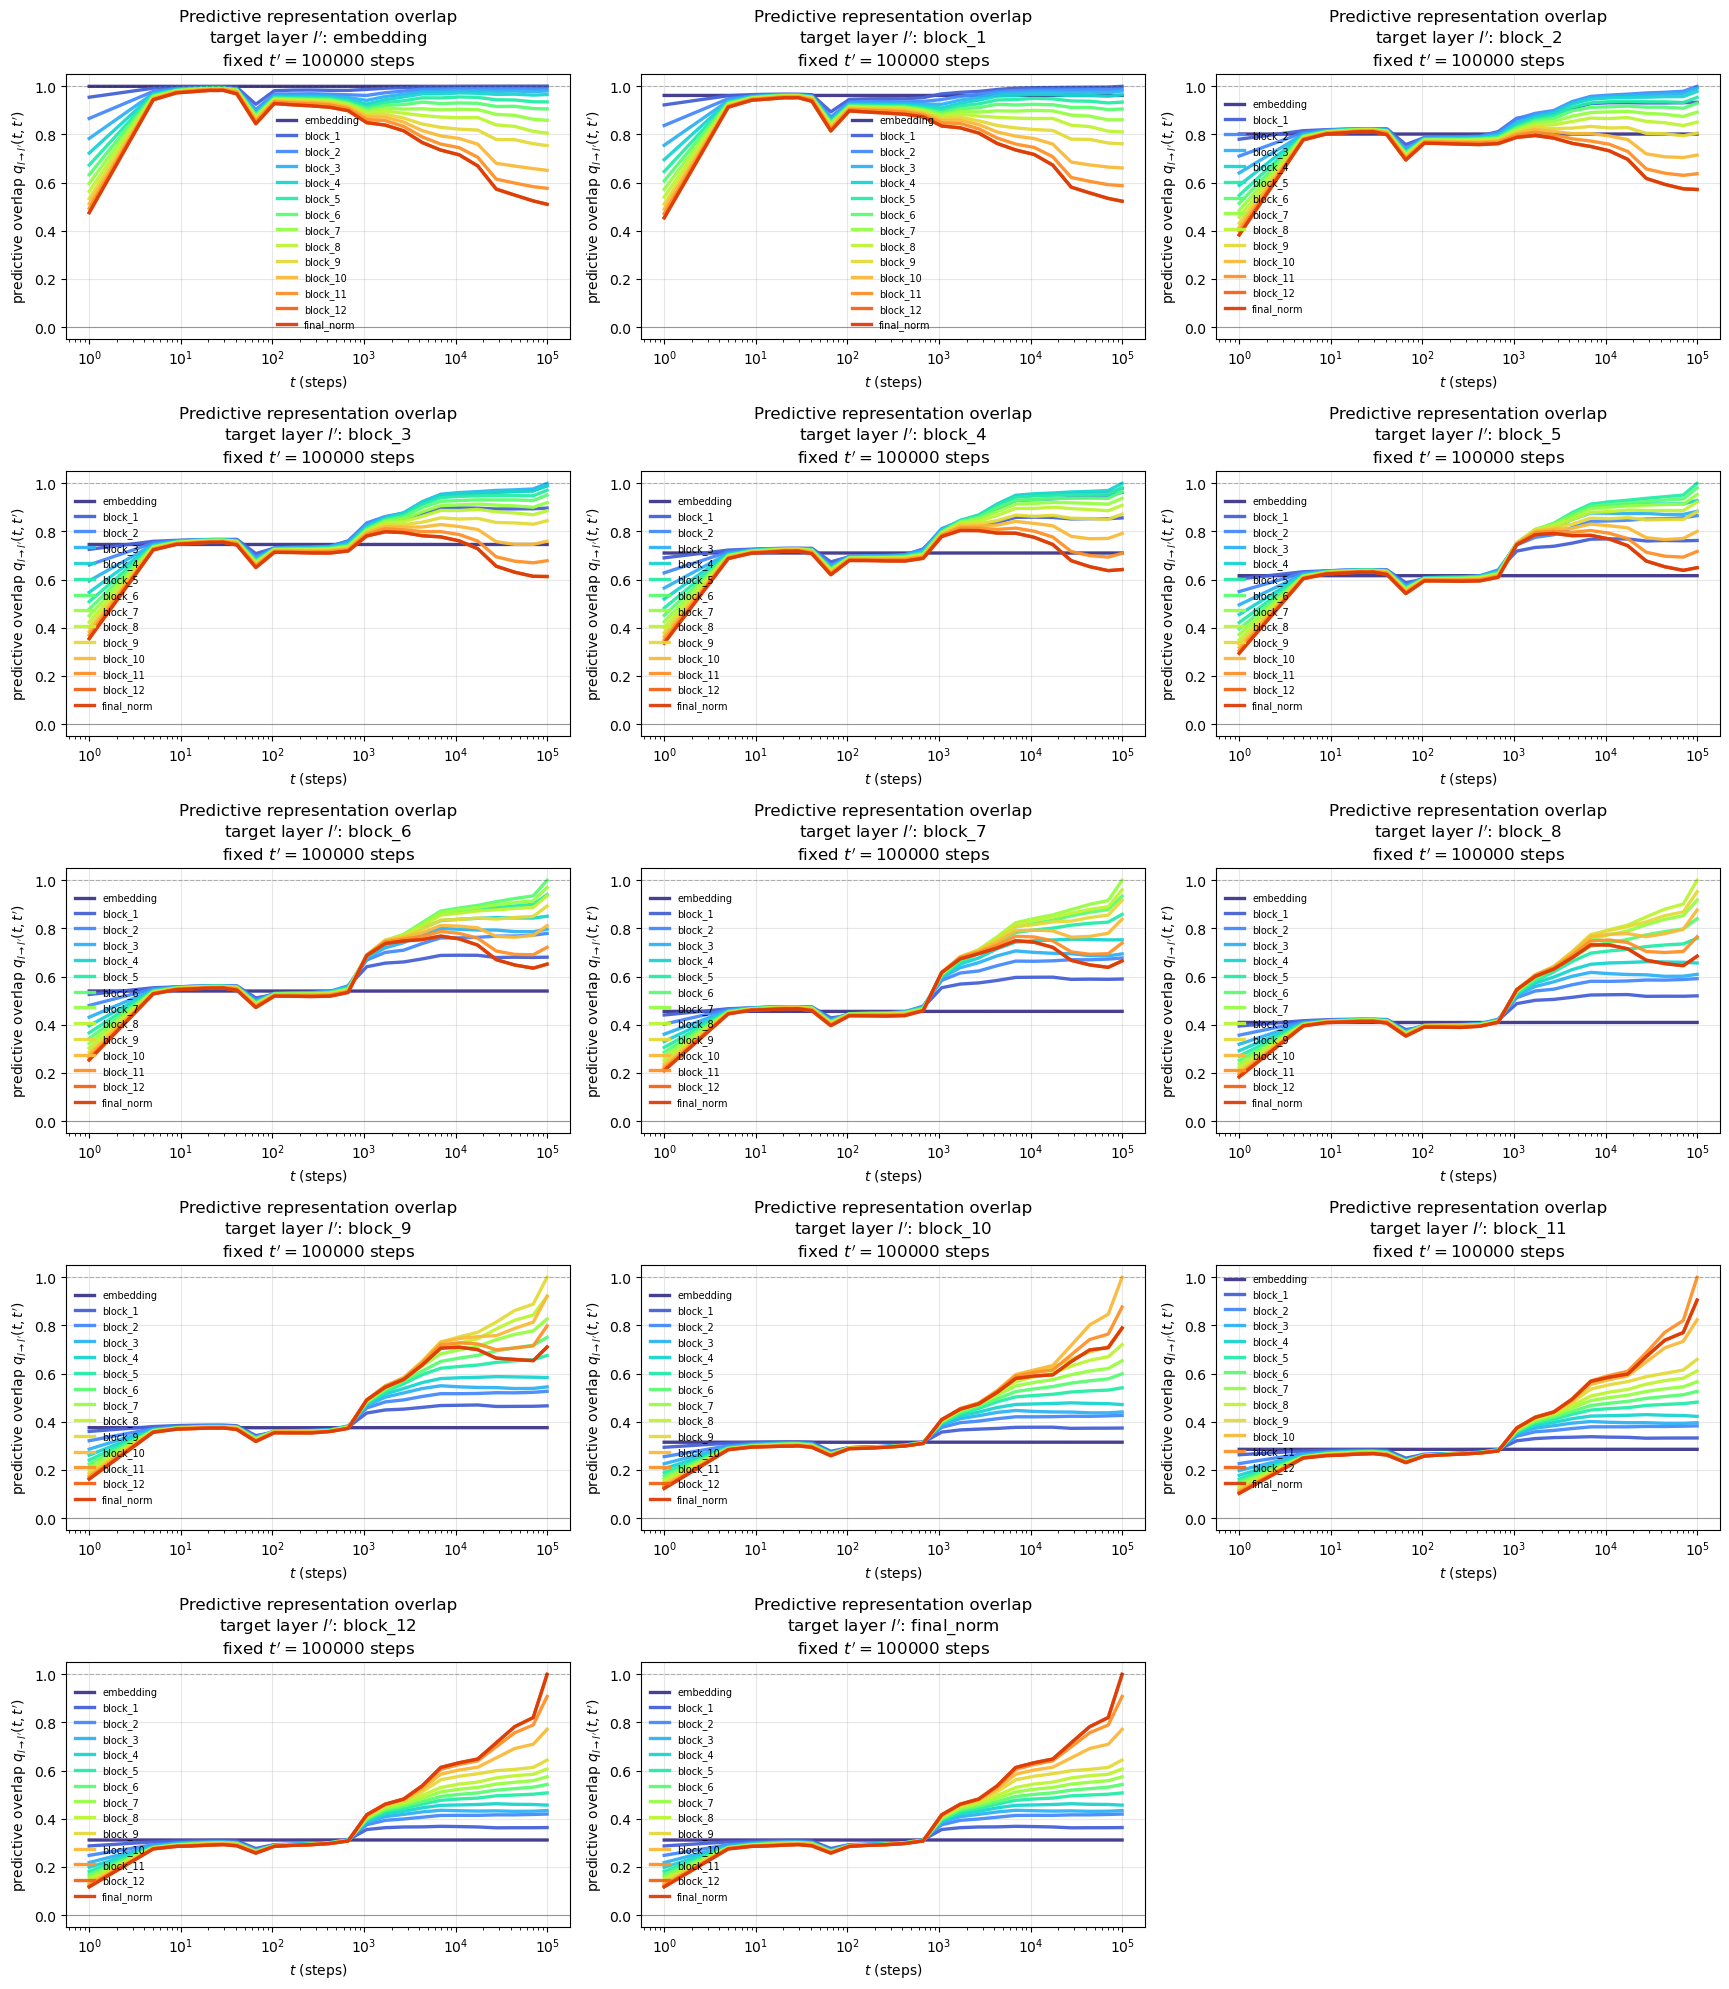

In [10]:

fig, axs, info = plot_predictive_all_source_layers_to_each_target_layer(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_predictive_TR2_ALL_L6_v1/",
    # or:
    # results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/",
    # output_name="YOUR_PREDICTIVE_OUTPUT_NAME",

    position="mean",          # average over token positions
    alpha_mode="position_mean",

    time_key="steps",
    x_mode="absolute",
    xscale="log",
    yscale="linear",

    ylim=None,                # no clipping: negative q values are visible
    ncols=3,
    title_prefix="Predictive representation overlap",
)

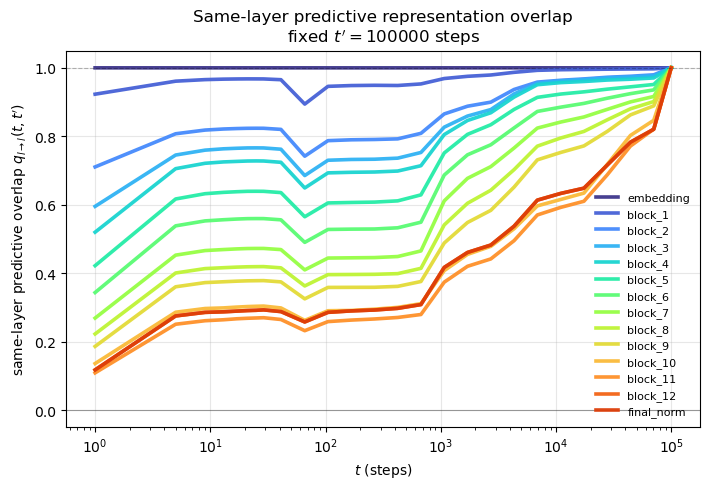

In [18]:
fig, ax, info = plot_predictive_same_layer_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_predictive_TR2_ALL_L6_v1/",
    position="mean",
    alpha_mode="position_mean",
    time_key="steps",
    x_mode="absolute",
    xscale="log",
    ylim=None,
)